# Exploratory Data Analysis

In [1]:
# importing the general dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Lets check what we have in our dataset

dataset_root = '/kaggle/input/affectnet-yolo-format/YOLO_format/'

for root, directories, files in os.walk(dataset_root):
    # Do something with the current directory path 'root'
    print("Current directory:", root)
    
    # Do something with the list of subdirectories 'directories'
    print("Subdirectories:", directories)
    
    # Do something with the list of files 'files'
    print("Files:", len(files))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/kaggle/input/affectnet-yolo-format/YOLO_format/valid/images'

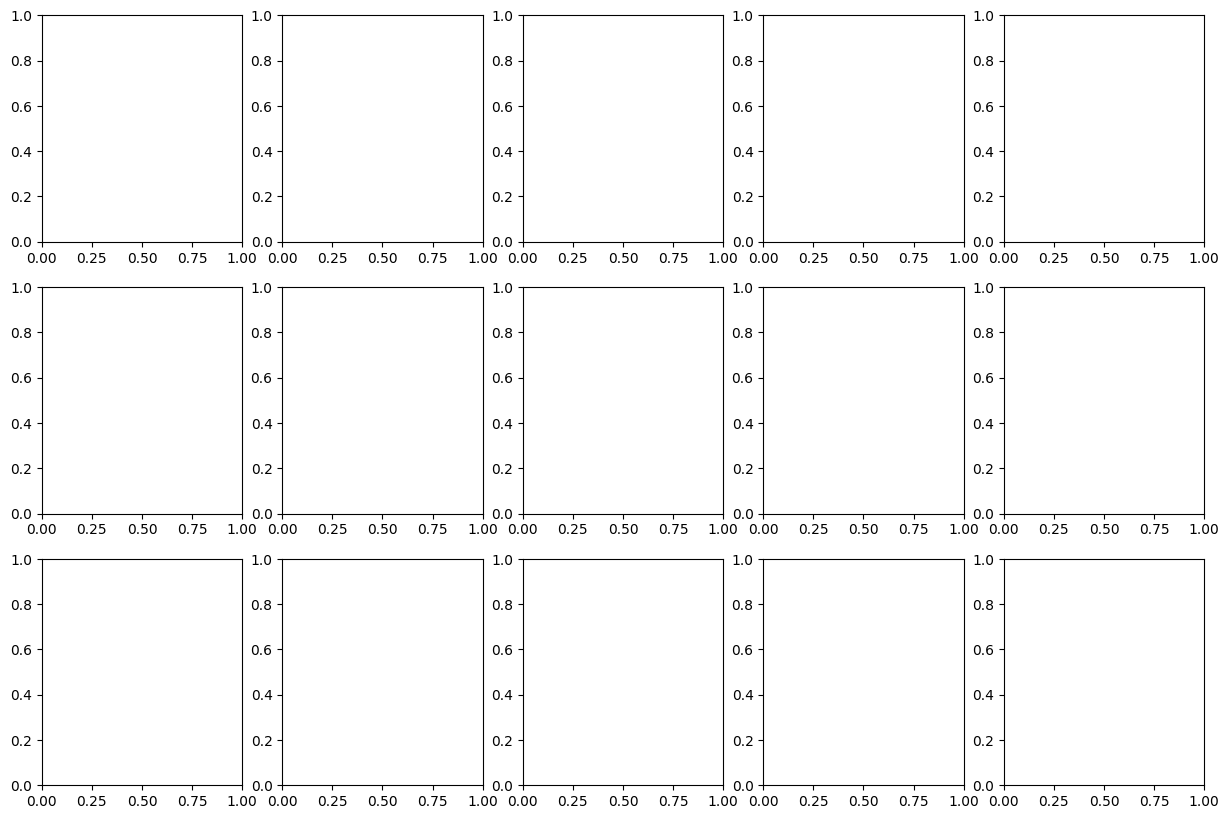

In [ ]:
# Lets observe some images from three folders

# Define the paths to the image folders
image_folders = [
    "/kaggle/input/affectnet-yolo-format/YOLO_format/valid/images",
    "/kaggle/input/affectnet-yolo-format/YOLO_format/test/images",
    "/kaggle/input/affectnet-yolo-format/YOLO_format/train/images"
]

# Define the number of images you want to display from each folder
num_images_per_folder = 5

# Create a subplot grid
fig, axes = plt.subplots(len(image_folders), num_images_per_folder, figsize=(15, 10))

# Loop through each image folder
for i, folder in enumerate(image_folders):
    image_files = os.listdir(folder)[:num_images_per_folder]  # Get the list of image files
    for j, image_file in enumerate(image_files):
        image_path = os.path.join(folder, image_file)
        try:
            # Open and display the image
            img = plt.imread(image_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
        except Exception as e:
            print(f"Error opening image: {image_path}")

# Adjust layout
plt.tight_layout()
plt.show()

/kaggle/input/affectnet-yolo-format/YOLO_format/train/labels/ffhq_5410.txt
/kaggle/input/affectnet-yolo-format/YOLO_format/train/images/ffhq_5410.png


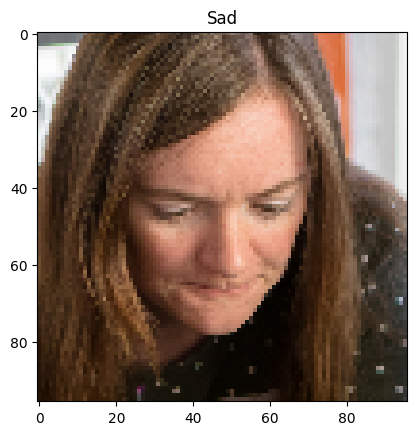

In [ ]:
# Lets observe an individual image with its corresponding label
labels_map = {
    '0' : 'Anger',
    '1' : 'Contempt',
    '2' : 'Disgust',
    '3' : 'Fear',
    '4' : 'Happy',
    '5' : 'Neutral',
    '6' : 'Sad',
    '7' : 'Surprise'
}

random_number = 333
train_images_path = '/kaggle/input/affectnet-yolo-format/YOLO_format/train/images'
random_image_path = os.path.join(train_images_path, os.listdir(train_images_path)[random_number])
random_image = plt.imread(random_image_path)

train_labels_path = '/kaggle/input/affectnet-yolo-format/YOLO_format/train/labels'
random_label_file = random_image_path.split('/')[-1].split('.')[0] + '.txt'
random_label_path = os.path.join(train_labels_path, random_label_file)

with open(random_label_path, 'r') as file:
    # first character is the label
    first_character = file.read(1)
image_class = labels_map[first_character]

print(random_label_path)
print(random_image_path)

plt.imshow(random_image)
plt.title(f'{image_class}')
plt.show()

In [ ]:
# Class frequencies
class_frequencies = np.array([])

# Define the paths to the image folders
label_folders = [
    "/kaggle/input/affectnet-yolo-format/YOLO_format/valid/labels",
    "/kaggle/input/affectnet-yolo-format/YOLO_format/test/labels",
    "/kaggle/input/affectnet-yolo-format/YOLO_format/train/labels"
]

# Iterate over each label directory (valid, test, train)
for label_dir in label_folders:
    
    # Iterate over each .txt file in the labels directory
    for file_name in os.listdir(label_dir):
        if file_name.endswith('.txt'):
            file_path = os.path.join(label_dir, file_name)
            
            # Read the first character of the file
            with open(file_path, 'r') as file:
                first_character = file.read(1)
        
        class_frequencies = np.append(class_frequencies, first_character)


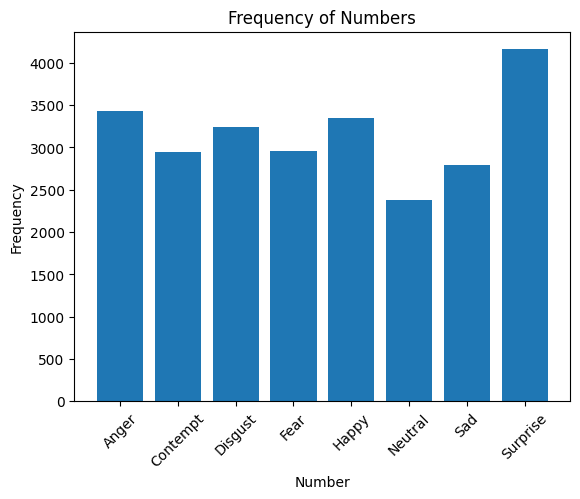

In [ ]:
unique, counts = np.unique(class_frequencies, return_counts=True)
unique_mapped = [labels_map[x] for x in unique]

# Create the bar plot
plt.bar(unique_mapped, counts)

# Add labels and title
plt.xlabel('Number')
plt.ylabel('Frequency')
plt.title('Frequency of Numbers')
plt.xticks(rotation=45)

# Show the plot
plt.show()

# YOLO Face Expression Detector

## Setup

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 921.9/921.9 kB 32.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from IPython.display import display, Image
from IPython import display
display.clear_output()

!yolo checks

Ultralytics 8.3.80 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6170.0/8062.4 GB disk)

OS                  Linux-6.6.56+-x86_64-with-glibc2.31
Environment         Kaggle
Python              3.10.13
Install             pip
RAM                 31.35 GB
Disk                6170.0/8062.4 GB
CPU                 Intel Xeon 2.00GHz
CPU count           4
GPU                 Tesla P100-PCIE-16GB, 16269MiB
GPU count           1
CUDA                12.1

numpy               ✅ 1.26.3<=2.1.1,>=1.23.0
WARNING ⚠️ invalid check_version(None, >=3.3.0) requested, please check values.
matplotlib          ✅ None>=3.3.0
opencv-python       ✅ 4.9.0.80>=4.6.0
pillow              ✅ 9.5.0>=7.1.2
pyyaml              ✅ 6.0.1>=5.3.1
requests            ✅ 2.31.0>=2.23.0
scipy               ✅ 1.12.0>=1.4.1
torch               ✅ 2.1.2>=1.8.0
torch               ✅ 2.1.2!=2.4.0,>=1.8.0; sys_platform == "win32"
torchvision         ✅ 0.16.2>=0.9.0
tqdm     

## Train the model with custom dataset

In [ ]:
import os
os.environ["WANDB_MODE"] = "disabled"

In [ ]:
!yolo task=detect \
mode=train \
model=yolo11n.pt \
data=/kaggle/input/affectnet-yolo-format/YOLO_format/data.yaml \
epochs=50 \
imgsz=640

100%|███████████████████████████████████████| 5.35M/5.35M [00:00<00:00, 158MB/s]
Ultralytics 8.3.80 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/kaggle/input/affectnet-yolo-format/YOLO_format/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=Fa

In [ ]:
os.listdir('/kaggle/working/runs/detect')

['train']

In [ ]:
# last epochs outputs
os.listdir('/kaggle/working/runs/detect/train')

['confusion_matrix_normalized.png',
 'P_curve.png',
 'train_batch2.jpg',
 'labels_correlogram.jpg',
 'results.csv',
 'PR_curve.png',
 'val_batch1_labels.jpg',
 'train_batch42762.jpg',
 'R_curve.png',
 'weights',
 'train_batch0.jpg',
 'args.yaml',
 'confusion_matrix.png',
 'train_batch1.jpg',
 'val_batch1_pred.jpg',
 'results.png',
 'labels.jpg',
 'val_batch0_labels.jpg',
 'val_batch2_labels.jpg',
 'val_batch2_pred.jpg',
 'train_batch42761.jpg',
 'train_batch42760.jpg',
 'F1_curve.png',
 'events.out.tfevents.1740679222.c78ffb0f6661.106.0',
 'val_batch0_pred.jpg']

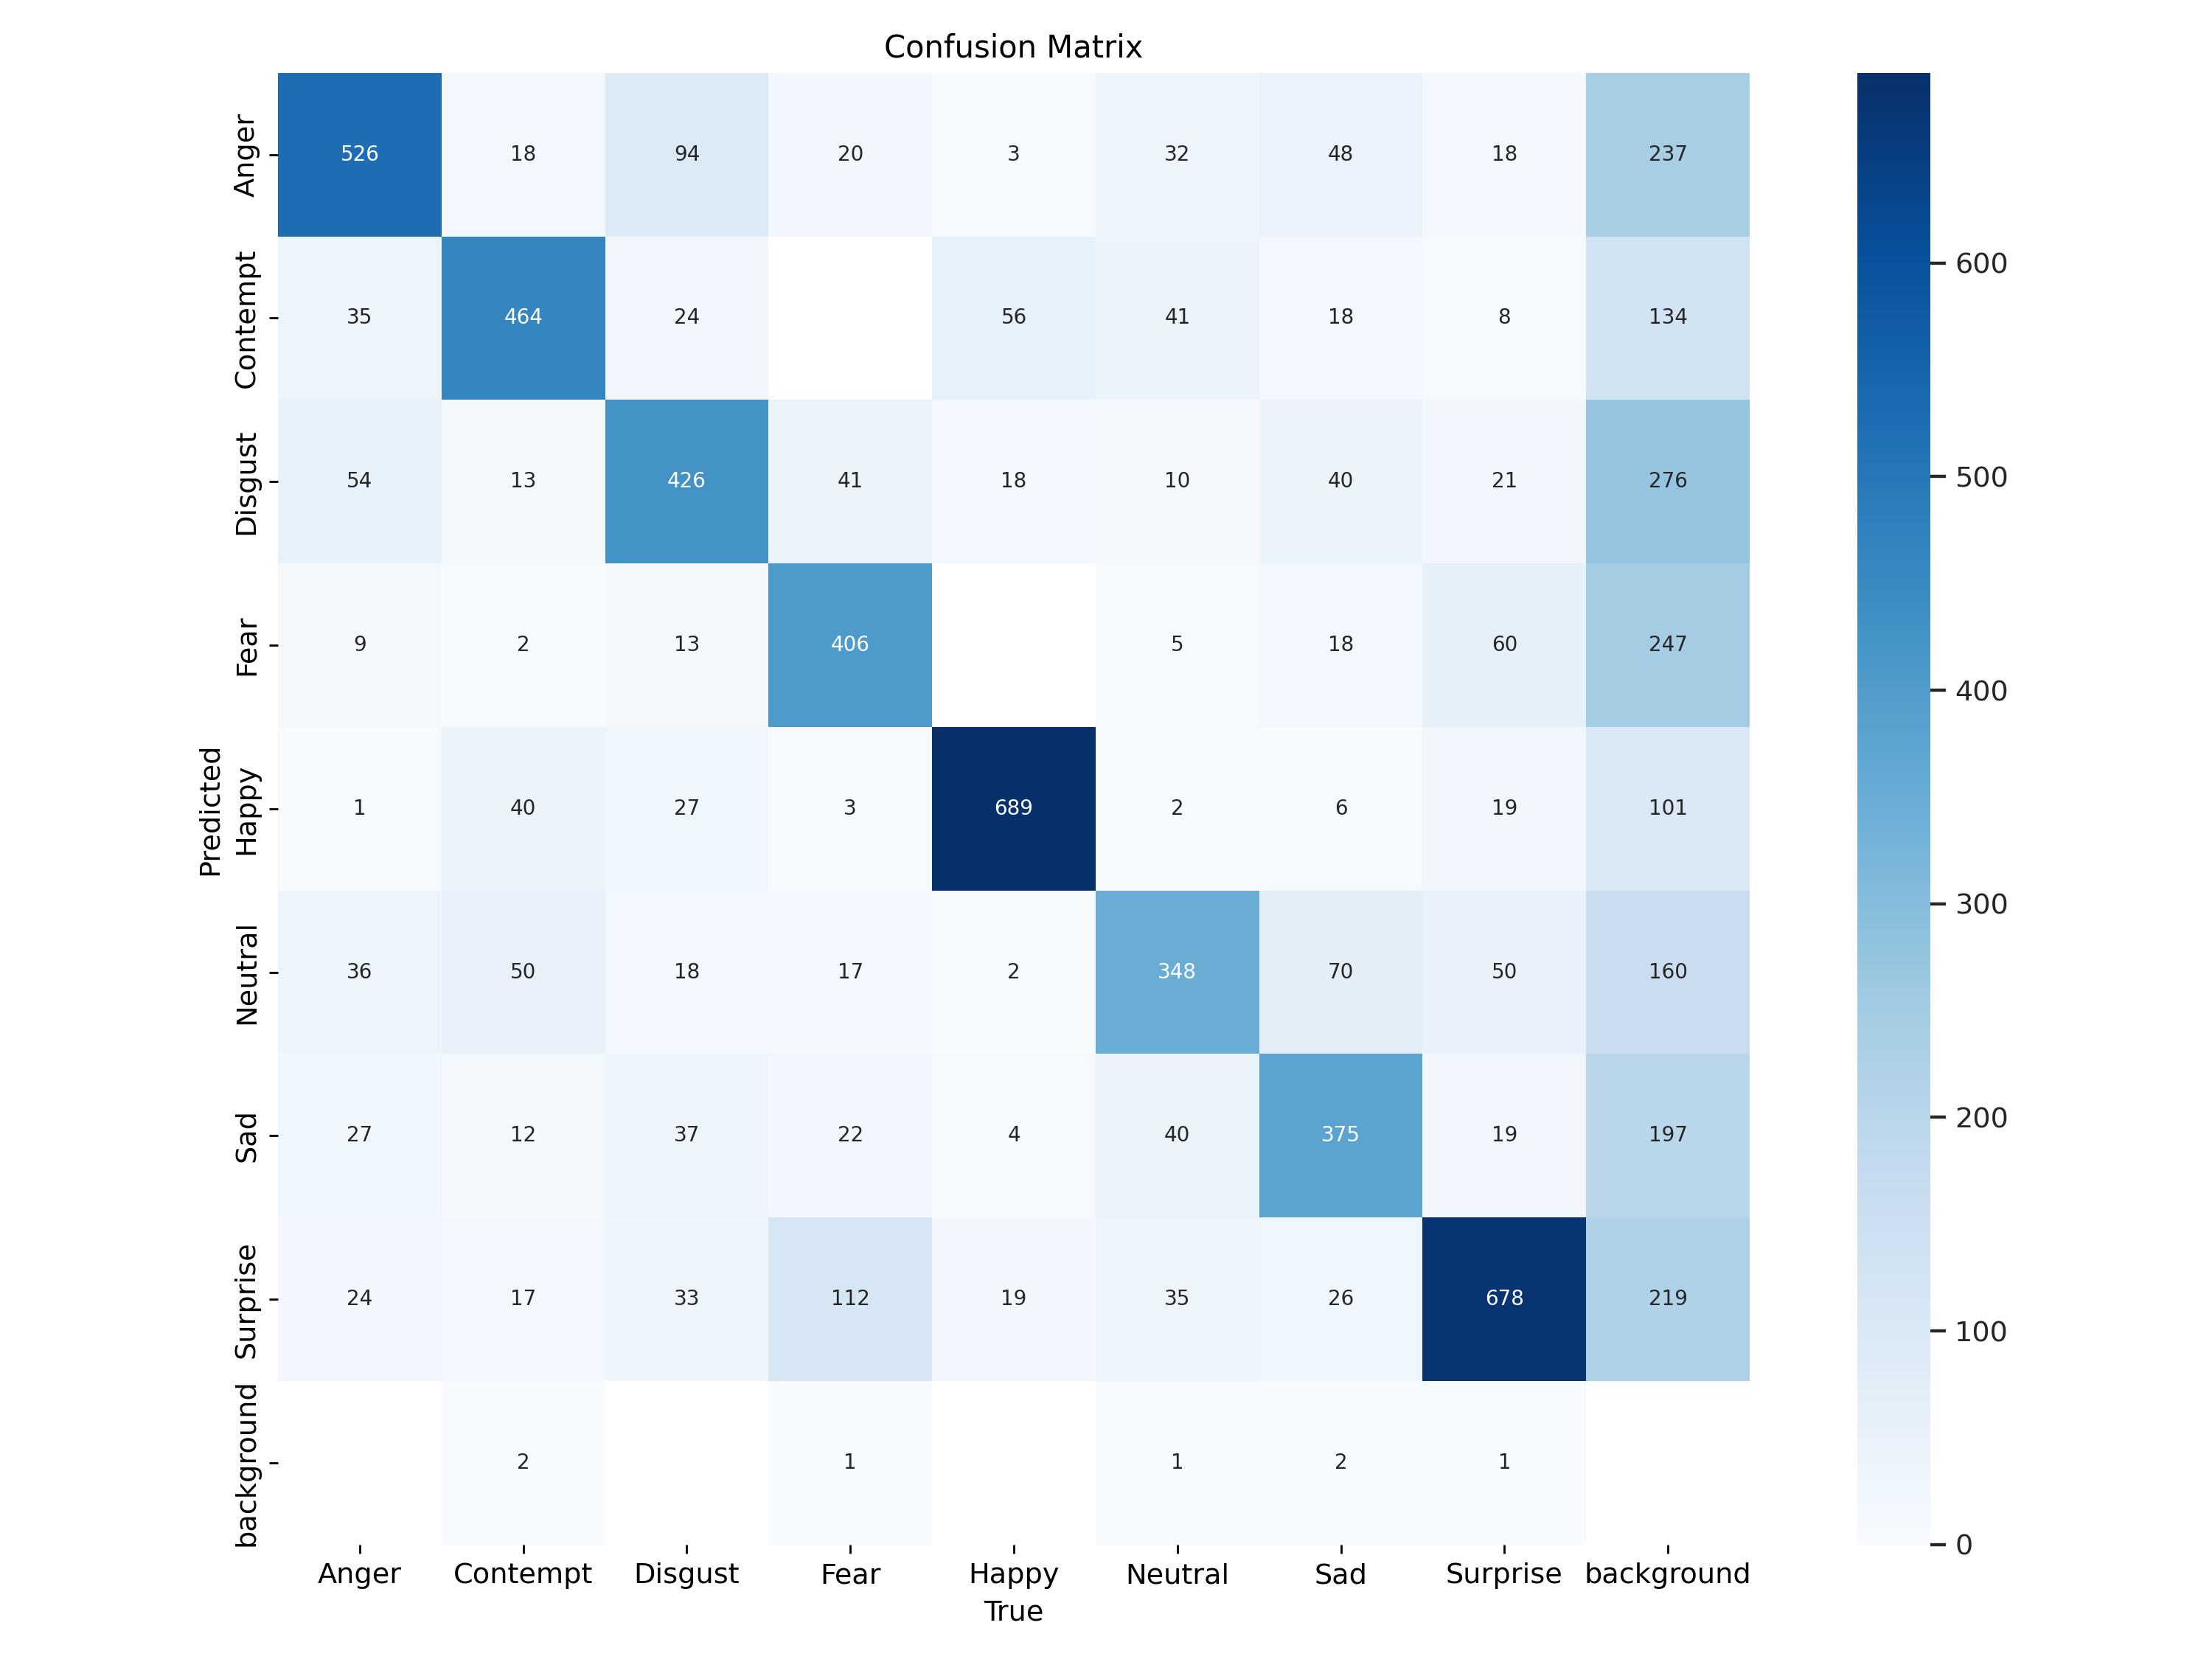

In [ ]:
Image(filename=f"/kaggle/working/runs/detect/train/confusion_matrix.png", width=1000)

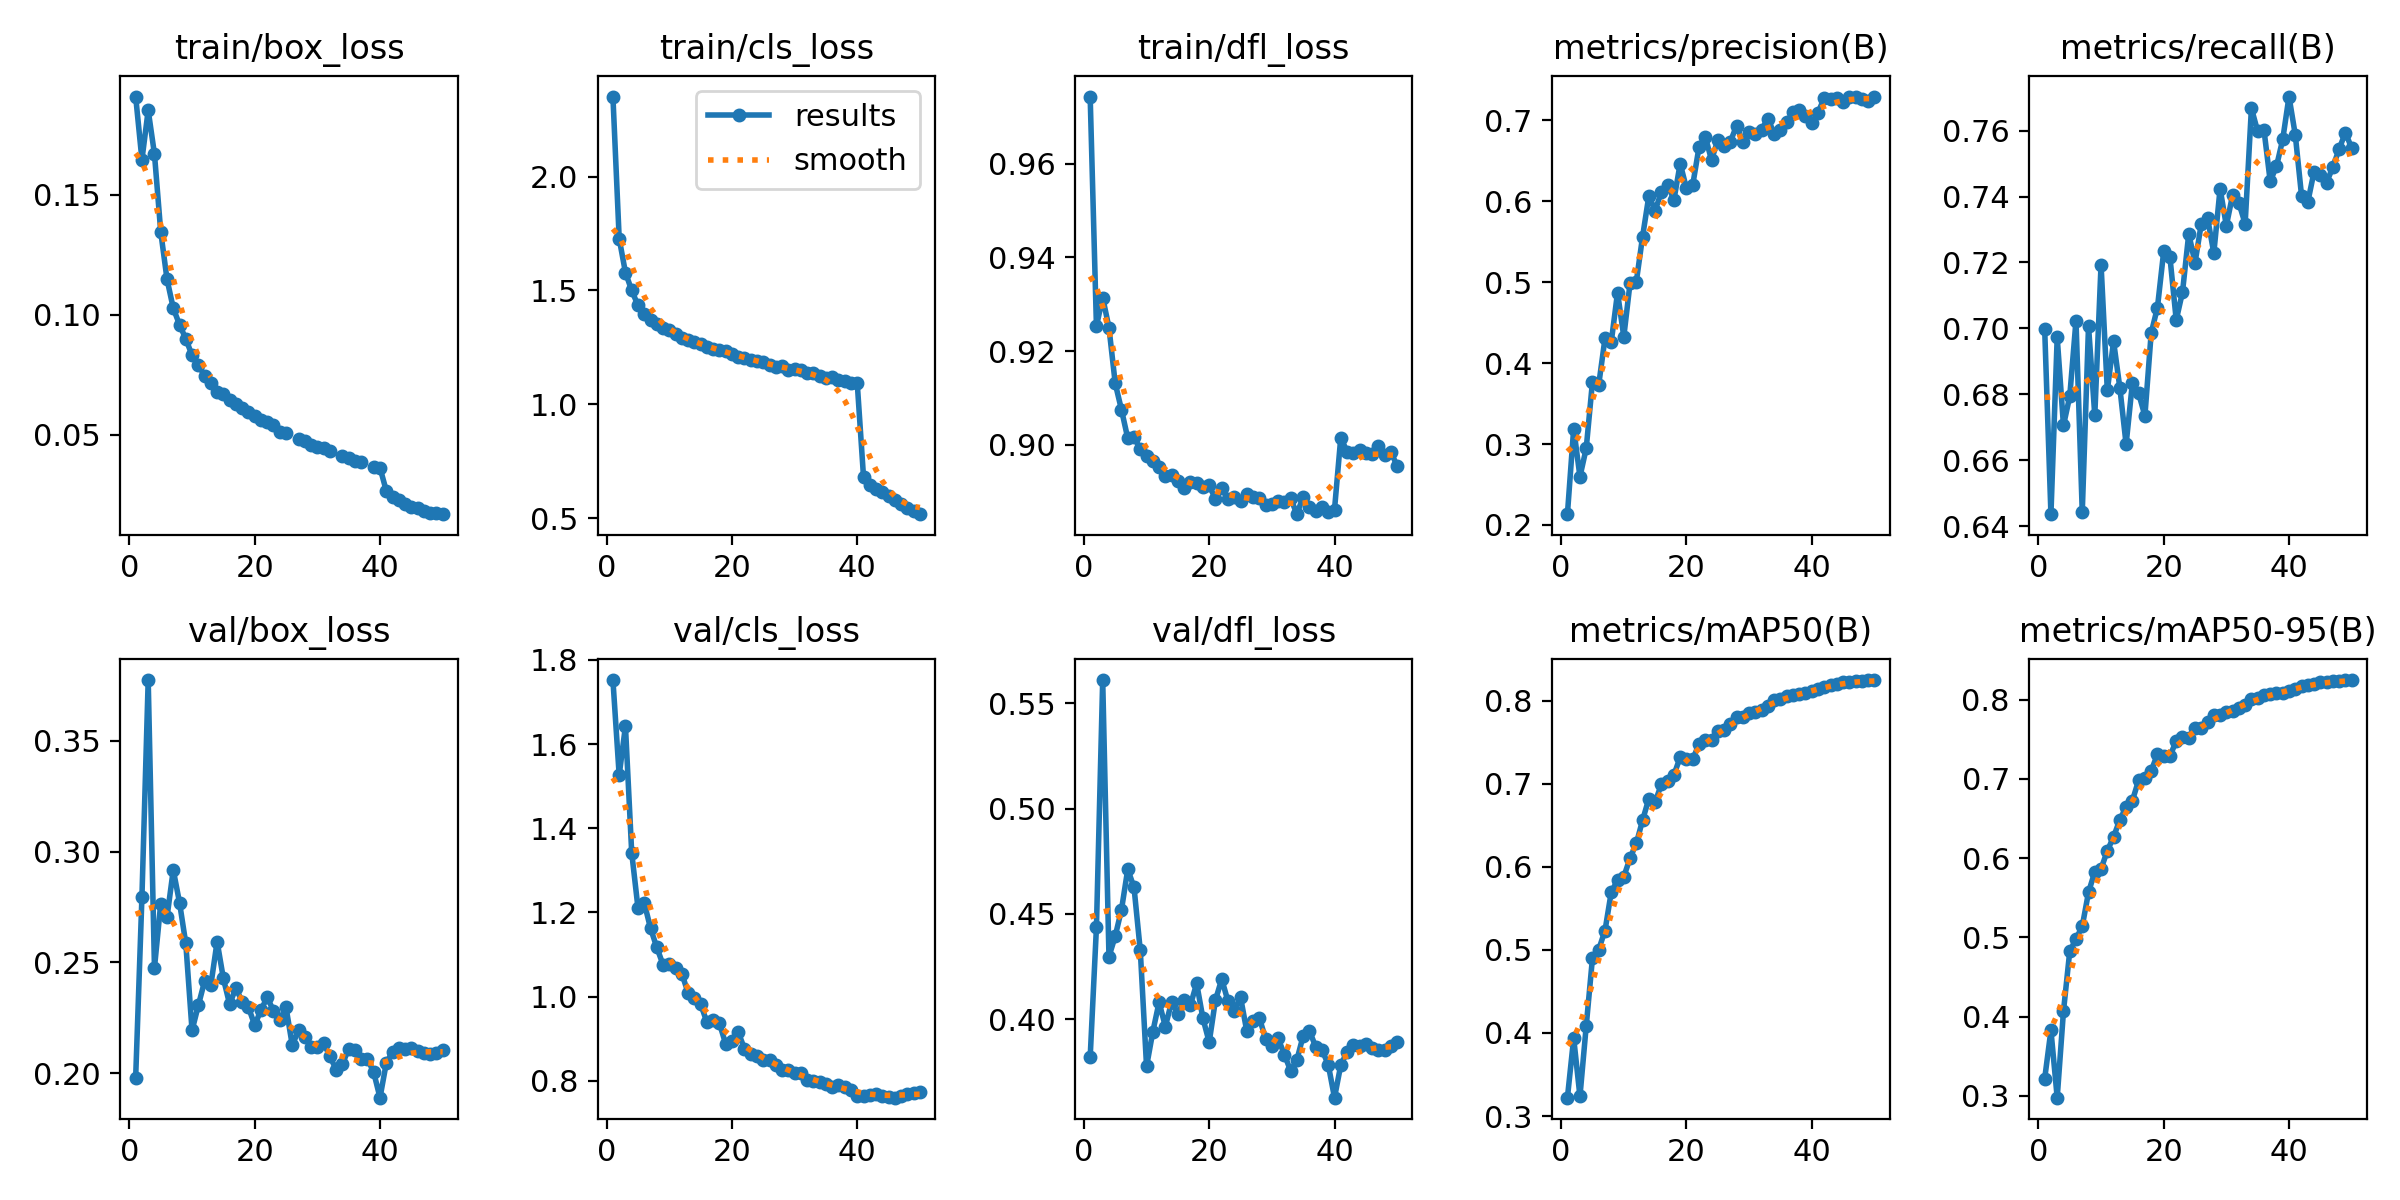

In [ ]:
Image(filename=f"/kaggle/working/runs/detect/train/results.png", width=1000)

In [ ]:
!yolo task=detect \
mode=val \
model=/kaggle/working/runs/detect/train/weights/last.pt \
data=/kaggle/input/affectnet-yolo-format/YOLO_format/data.yaml

Ultralytics 8.3.80 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 100 layers, 2,583,712 parameters, 0 gradients, 6.3 GFLOPs
val: Scanning /kaggle/input/affectnet-yolo-format/YOLO_format/valid/labels... 54
val: WARNING ⚠️ Cache directory /kaggle/input/affectnet-yolo-format/YOLO_format/valid is not writeable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  m
                   all       5406       5406      0.729      0.754      0.825      0.825
                 Anger        712        712      0.699      0.786      0.828      0.828
              Contempt        618        618      0.738      0.756      0.844      0.844
               Disgust        672        672      0.692       0.71       0.79       0.79
                  Fear        622        622      0.758      0.745      0.842      0.842
                 Happy        791        791      0.866      0.891      0.955      0.955
            

## Save the model

In [ ]:
!cp yolo11n.pt /kaggle/working/

cp: 'yolo11n.pt' and '/kaggle/working/yolo11n.pt' are the same file


## Validate the Model

In [ ]:
!yolo task=detect \
mode=val \
model=/kaggle/working/runs/detect/train/weights/best.pt \
data=/kaggle/input/affectnet-yolo-format/YOLO_format/data.yaml

Ultralytics 8.3.80 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 100 layers, 2,583,712 parameters, 0 gradients, 6.3 GFLOPs
val: Scanning /kaggle/input/affectnet-yolo-format/YOLO_format/valid/labels... 54
val: WARNING ⚠️ Cache directory /kaggle/input/affectnet-yolo-format/YOLO_format/valid is not writeable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  m
                   all       5406       5406      0.729      0.754      0.825      0.825
                 Anger        712        712      0.699      0.786      0.828      0.828
              Contempt        618        618      0.738      0.756      0.844      0.844
               Disgust        672        672      0.692       0.71       0.79       0.79
                  Fear        622        622      0.758      0.745      0.842      0.842
                 Happy        791        791      0.866      0.891      0.955      0.955
            

## Predict

In [ ]:
!yolo task=detect \
mode=predict \
model=/kaggle/working/runs/detect/train/weights/best.pt \
conf=0.25 \
source=/kaggle/input/affectnet-yolo-format/YOLO_format/test/images

Ultralytics 8.3.80 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 100 layers, 2,583,712 parameters, 0 gradients, 6.3 GFLOPs

image 1/2755 /kaggle/input/affectnet-yolo-format/YOLO_format/test/images/ffhq_1002.png: 640x640 1 Neutral, 8.0ms
image 2/2755 /kaggle/input/affectnet-yolo-format/YOLO_format/test/images/ffhq_1014.png: 640x640 1 Contempt, 8.3ms
image 3/2755 /kaggle/input/affectnet-yolo-format/YOLO_format/test/images/ffhq_102.png: 640x640 1 Happy, 8.7ms
image 4/2755 /kaggle/input/affectnet-yolo-format/YOLO_format/test/images/ffhq_103.png: 640x640 1 Happy, 8.0ms
image 5/2755 /kaggle/input/affectnet-yolo-format/YOLO_format/test/images/ffhq_1033.png: 640x640 1 Happy, 7.8ms
image 6/2755 /kaggle/input/affectnet-yolo-format/YOLO_format/test/images/ffhq_1034.png: 640x640 1 Neutral, 7.6ms
image 7/2755 /kaggle/input/affectnet-yolo-format/YOLO_format/test/images/ffhq_1037.png: 640x640 1 Anger, 7.3ms
image 8/2755 /kaggle/input/affectnet-yolo-form